In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## One Perceptron

In [15]:
class Sn:
    def __init__(self, rate = 0.015, iterations = 1000):
        self.rate = rate
        self.iterations = iterations
        self.weights = None

    def _sigmoid(self,z):
        return 1/(1+np.exp(-z))

    def _log_loss(self, y, p):
        epsilon = 1e-15
        p_adj = np.clip(p,epsilon, 1-epsilon)
        loss = -np.mean(y*np.log(p_adj) + (1-y)*np.log(1-p_adj))
        return loss

    def fit(self, X, y):

        rows, cols = X.shape
        
        #initialize the weights
        self.weights = np.random.normal(loc = 0, scale = 0.015, size = cols+1)

        #Augmenting X with column of ones at the extreme left
        X_aug = np.hstack((np.ones((rows,1)),X))

        #Gradient Descent
        for i in range(self.iterations):

            #linear model
            z = np.dot(X_aug, self.weights)
            p = self._sigmoid(z)

            if i%100 == 0: print(self._log_loss(y, p))
            
            #Compute Gradient
            dw = (1/rows)*np.dot(X_aug.T, p - y)

            #update weights
            self.weights = self.weights - self.rate * dw

    def predict_proba(self, X):
        X_aug = np.hstack((np.ones((X.shape[0], 1)), X))
        model = np.dot(X_aug, self.weights)
        return self._sigmoid(model)
        
    def predict(self, X):
        threshold = 0.5
        y_hat = self.predict_proba(X)
        y_zero_one = [1 if i>=threshold else 0 for i in y_hat]
        return np.array(y_zero_one)
        

## Importing the dataset

In [32]:
dataset = pd.read_csv('Age_Salary_Buy.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

## Splitting the dataset into the Training set and Test set

In [33]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

## Feature Scaling

In [34]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

# Compute the means and standard deviations of features w.r.t
# training set. Transform X_train
X_train = sc.fit_transform(X_train)

# Using the scaler computed above, transform X_test
X_test = sc.transform(X_test)

## Training the Simple Network model on the Training set

In [39]:
classifier = Sn(rate = 0.05, iterations = 10000)
classifier.fit(X_train, y_train)

0.6916573612620599
0.4511484626015267
0.40721062428906984
0.39102426911449933
0.383297556619387
0.3790924051912634
0.3766166644080331
0.3750814634198497
0.3740941451509178
0.3734419733269343
0.3730023728556737
0.37270137059870345
0.37249269907451416
0.3723465929752865
0.37224346700246674
0.3721701969318332
0.37211785595493646
0.37208029713431245
0.37205324433894865
0.3720336974587439
0.3720195365836996
0.37200925476449515
0.3720017753548331
0.3719963258493798
0.37199234995894903
0.37198944586236804
0.37198732255618466
0.3719857688238782
0.37198463106964036
0.3719837974188294
0.37198318627295535
0.3719827380461213
0.3719824091829827
0.37198216781862553
0.37198199062366105
0.37198186050709875
0.3719817649414221
0.3719816947398583
0.3719816431628328
0.3719816052644055
0.3719815774138708
0.3719815569453453
0.3719815419009609
0.3719815308425643
0.3719815227135949
0.37198151673773
0.3719815123444908
0.3719815091146205
0.37198150673997316
0.37198150499405047
0.3719815037103578
0.3719815027665

## Predicting the Training Set Results

In [ ]:
y_pred = classifier.predict(X_train)

## Making the Confusion Matrix for the Training Set

In [21]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_train, y_pred)
print(cm)
print(accuracy_score(y_train, y_pred))

[[171  18]
 [ 36  75]]
0.82


## Predicting the Test set results

In [22]:
y_pred_test = classifier.predict(X_test)

## Making the Confusion Matrix for the Test Set

In [23]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm_test = confusion_matrix(y_test, y_pred_test)
print(cm_test)
print(accuracy_score(y_test, y_pred_test))

[[65  3]
 [ 8 24]]
0.89


## Applying Logistic Regression on the same Data

In [ ]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 0)
classifier.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,0
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [26]:
y1_pred = classifier.predict(X_test)

In [27]:
cm1 = confusion_matrix(y_test, y1_pred)
print(cm1)
accuracy_score(y_test, y1_pred)

[[65  3]
 [ 8 24]]


0.89

## Visualising the Training set results

C:\Users\omar\AppData\Local\Temp\ipykernel_5368\3592760932.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)


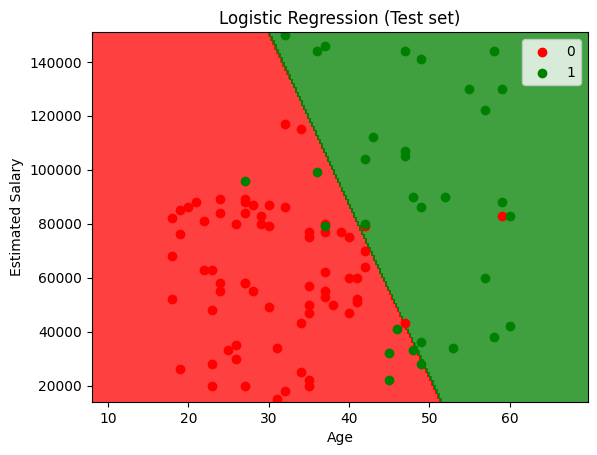

In [29]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_test), y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))
plt.contourf(X1, X2, classif.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Logistic Regression (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()